                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     653.3
Date:                Thu, 27 Mar 2025   Prob (F-statistic):           5.22e-57
Time:                        03:35:33   Log-Likelihood:                -147.62
No. Observations:                 100   AIC:                             301.2
Df Residuals:                      97   BIC:                             309.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0196      0.883      2.287      0.0

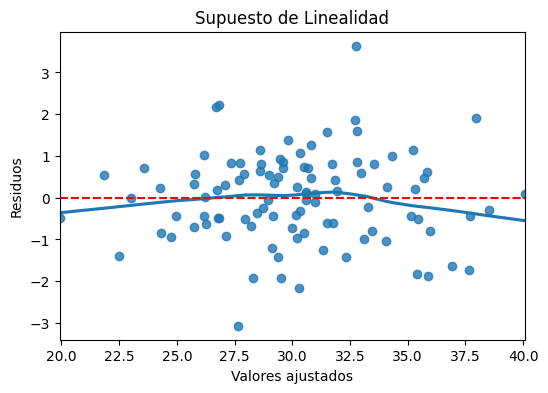

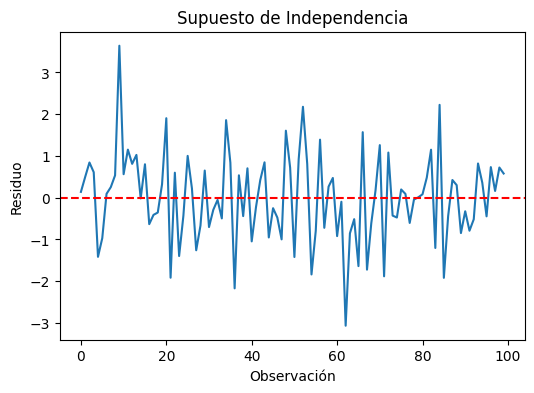

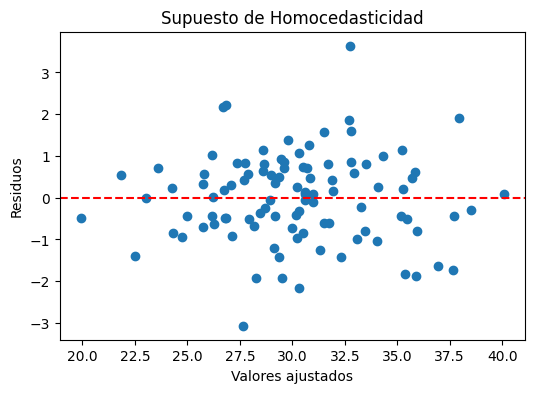

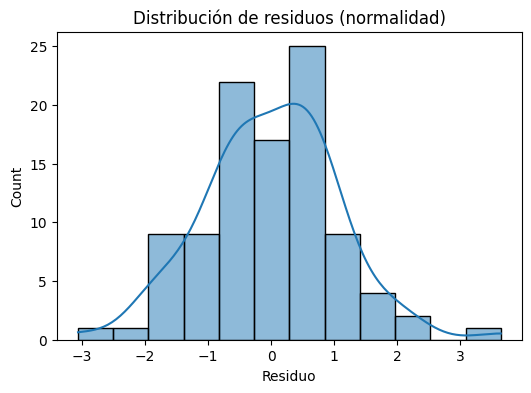


Prueba de Shapiro-Wilk: p-value = 0.4757 (Normalidad)

Factores de inflación de la varianza (VIF):
  Variable        VIF
0    const  67.434307
1       X1   1.018964
2       X2   1.018964


In [ ]:
# Paso 1: Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

# Paso 2: Crear un dataset simulado
np.random.seed(42)
n = 100
X1 = np.random.normal(10, 2, n)
X2 = np.random.normal(5, 1, n)
error = np.random.normal(0, 1, n)
Y = 3 + 2*X1 + 1.5*X2 + error

df = pd.DataFrame({'X1': X1, 'X2': X2, 'Y': Y})

# Paso 3: Ajustar modelo de regresión lineal múltiple usando EMCO
X = sm.add_constant(df[['X1', 'X2']])  # Agrega el intercepto
modelo = sm.OLS(df['Y'], X).fit()

print(modelo.summary())

# Paso 4: Diagnóstico de los supuestos

# 1. Supuesto de linealidad
plt.figure(figsize=(6,4))
sns.residplot(x=modelo.fittedvalues, y=modelo.resid, lowess=True)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Supuesto de Linealidad')
plt.show()

# 2. Supuesto de independencia (gráfico de residuos en orden)
plt.figure(figsize=(6,4))
plt.plot(modelo.resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('Supuesto de Independencia')
plt.xlabel('Observación')
plt.ylabel('Residuo')
plt.show()

# 3. Supuesto de homocedasticidad
plt.figure(figsize=(6,4))
plt.scatter(modelo.fittedvalues, modelo.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Supuesto de Homocedasticidad')
plt.show()

# 4. Supuesto de normalidad de los errores
plt.figure(figsize=(6,4))
sns.histplot(modelo.resid, kde=True)
plt.title('Distribución de residuos (normalidad)')
plt.xlabel('Residuo')
plt.show()

# Prueba de Shapiro-Wilk
stat, p = shapiro(modelo.resid)
print(f'\nPrueba de Shapiro-Wilk: p-value = {p:.4f} {"(No normalidad)" if p < 0.05 else "(Normalidad)"}')

# 5. Supuesto de no multicolinealidad (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nFactores de inflación de la varianza (VIF):")
print(vif_data)